<a href="https://colab.research.google.com/github/iisratislam/GNN-Multimodal-Fraud-Detection/blob/main/01_Multimodal_EDA_and_Baseline_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01: Initial Data Audit and Multimodal Baseline
**Project:** Robust Financial Fraud Detection using GNNs and Multimodal Fusion  
**Research Goal:** Establish a performance baseline and perform a data audit on the IEEE-CIS dataset.  
**Author:** Israt Islam  
**Framework:** Google Colab + Google Drive Integration

## 1. Setup and Infrastructure
We mount Google Drive to access the dataset and import essential libraries for data science and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc
from google.colab import drive
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Change directory to your specific folder
# This ensures all saves (models/images) go directly to your Drive
%cd /content/drive/MyDrive/FraudProject

sns.set(style="whitegrid")
print("Environment Ready. Current Directory:", os.getcwd())

Mounted at /content/drive
/content/drive/MyDrive/FraudProject
Environment Ready. Current Directory: /content/drive/MyDrive/FraudProject


## 2. Computational Efficiency: Memory Management
The IEEE-CIS dataset is large (~1.2GB). We implement a downcasting function to optimize numerical types, which significantly reduces the RAM footprint without losing data integrity.

In [5]:
def reduce_mem_usage(df):
    """ Iterate through columns and modify data types to reduce memory usage. """
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min, c_max = df[col].min(), df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
    return df

## 3. Multimodal Data Integration
We load the Transaction and Identity files and perform a left-join on 'TransactionID'. This unifies behavioral data with digital fingerprints.

In [6]:
# 1. Navigate to the folder (Run this once)
%cd /content/drive/MyDrive/FraudProject

# 2. Load the data
# (Since we are already in the folder, we just use the filenames)
print("Loading Transaction data...")
train_trans = reduce_mem_usage(pd.read_csv('train_transaction.csv'))

print("Loading Identity data...")
train_id = reduce_mem_usage(pd.read_csv('train_identity.csv'))

# 3. Merge into a single Multimodal Dataset
print("Merging datasets...")
train = pd.merge(train_trans, train_id, on='TransactionID', how='left')

# 4. Create engineered feature: null_count
train['null_count'] = train.isnull().sum(axis=1)

# 5. Clean up memory
del train_trans, train_id
gc.collect()

print(f"✅ Success! Merged Dataset Shape: {train.shape}")

/content/drive/MyDrive/FraudProject
Loading Transaction data...


/tmp/ipython-input-492/1139349258.py:15: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipython-input-492/1139349258.py:15: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipython-input-492/1139349258.py:15: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipython-input-492/1139349258.py:15: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipython-input-492/1139349258.py:15: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipython-input-492/1139349258.py:15: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipython-input-492/11393

Loading Identity data...


/tmp/ipython-input-492/1139349258.py:15: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:


Merging datasets...
✅ Success! Merged Dataset Shape: (590540, 435)


### 3.5. Correlation Heatmap of Key Features
We visualize the relationships between numerical features to identify multicollinearity and understand which variables have the strongest linear relationship with $isFraud$.

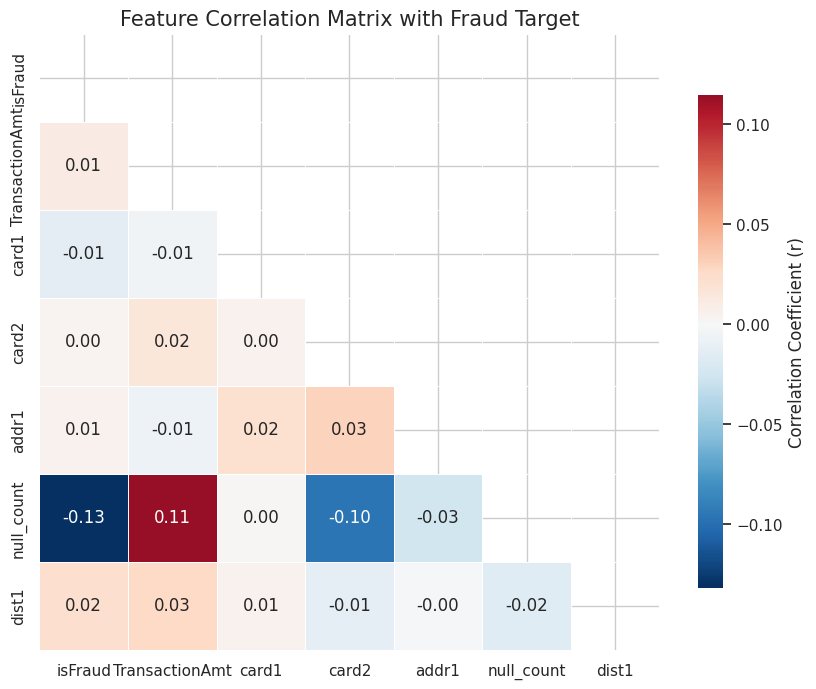

In [11]:
# Selecting multimodal features for correlation
corr_features = ['isFraud', 'TransactionAmt', 'card1', 'card2', 'addr1', 'null_count', 'dist1']
plt.figure(figsize=(10, 8))

# Calculate correlation matrix
corr_matrix = train[corr_features].corr()

# Create a mask for the upper triangle (cleaner look)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plotting with cbar (the legend)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='RdBu_r',
            center=0, linewidths=.5, cbar_kws={"shrink": .8, "label": "Correlation Coefficient (r)"})

plt.title('Feature Correlation Matrix with Fraud Target', fontsize=15)
plt.show()

### 3.6. Temporal Patterns in Fraud
The `TransactionDT` field is a time delta in seconds. We convert this into a "Hour of Day" feature to see if fraudulent activity spikes during specific hours (e.g., late at night when monitoring might be lower).

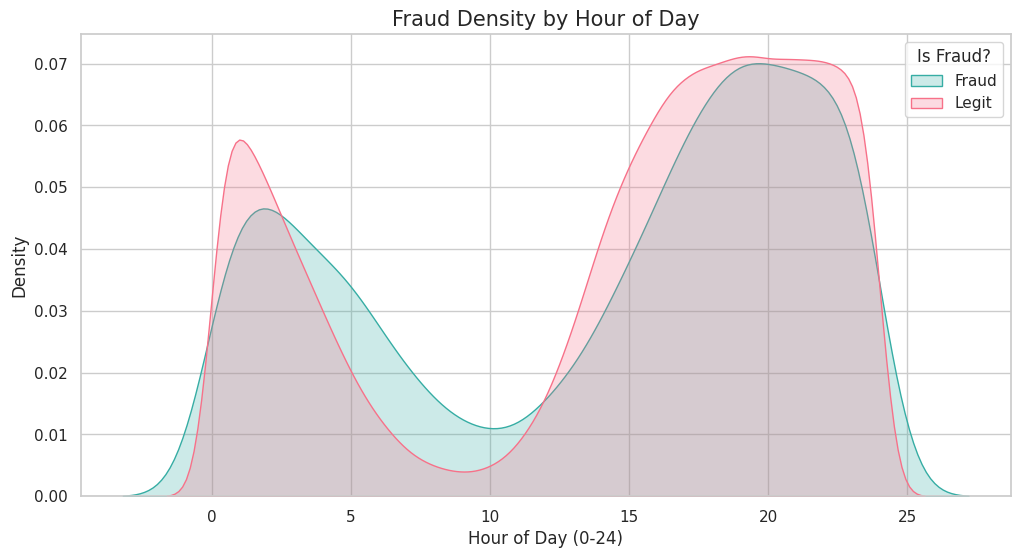

In [10]:
# Simple conversion: 86400 seconds in a day
train['hours'] = (train['TransactionDT'] / (3600)) % 24

plt.figure(figsize=(12, 6))
sns.kdeplot(data=train, x='hours', hue='isFraud', common_norm=False, fill=True, palette='husl')
plt.title('Fraud Density by Hour of Day', fontsize=15)
plt.xlabel('Hour of Day (0-24)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Is Fraud?', labels=['Fraud', 'Legit'])
plt.show()

### 3.7. Fraud Distribution by Device Type
As part of our multimodal audit, we examine the `DeviceType` feature. This helps us understand if fraud is more prevalent on Mobile vs. Desktop platforms, which is critical for identifying bot-driven synthetic identity attacks.

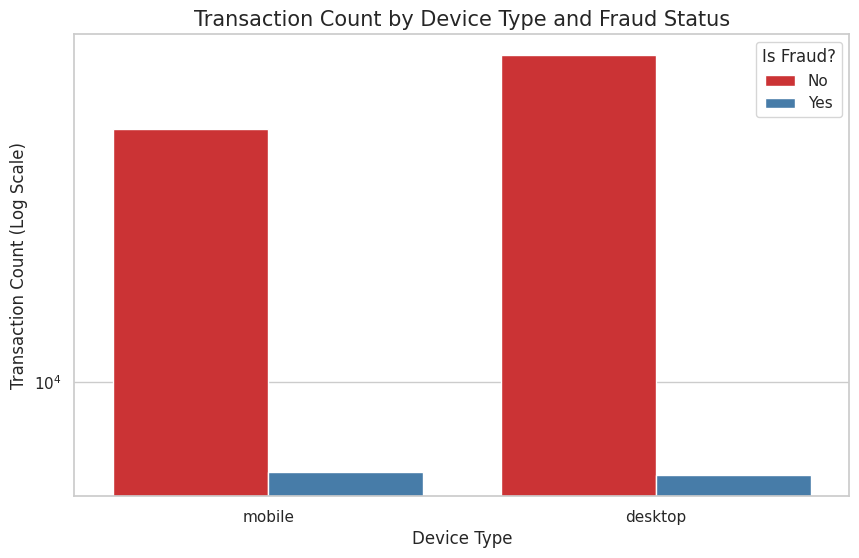

In [12]:
# Check for nulls and plot
plt.figure(figsize=(10, 6))
device_data = train.dropna(subset=['DeviceType'])

ax = sns.countplot(data=device_data, x='DeviceType', hue='isFraud', palette='Set1')
plt.title('Transaction Count by Device Type and Fraud Status', fontsize=15)
plt.xlabel('Device Type', fontsize=12)
plt.ylabel('Transaction Count (Log Scale)', fontsize=12)
plt.yscale('log') # Log scale because legitimate transactions are so numerous
plt.legend(title='Is Fraud?', labels=['No', 'Yes'])

plt.show()

### 3.8. Regional Fraud Analysis (addr1)
`addr1` represents the billing region. We visualize the top 10 regions by transaction volume to see if certain areas have a disproportionate amount of fraud.

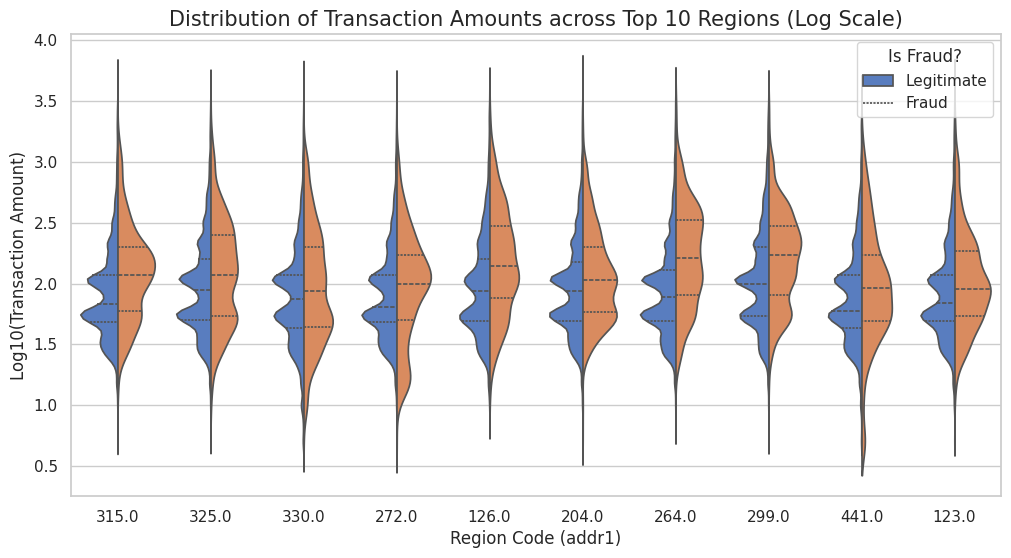

In [15]:
# 1. Get top 10 regions by volume
top_regions = train['addr1'].value_counts().nlargest(10).index
region_data = train[train['addr1'].isin(top_regions)].copy()

# 2. Manually create log amount and cast to float32 to avoid NotImplementedError
region_data['Log_TransactionAmt'] = np.log10(region_data['TransactionAmt']).astype('float32')
region_data['addr1'] = region_data['addr1'].astype('str') # Cast to string for better categorical plotting

plt.figure(figsize=(12, 6))
# Using split=True to compare the two classes side-by-side inside each 'violin'
sns.violinplot(data=region_data, x='addr1', y='Log_TransactionAmt', hue='isFraud',
               split=True, inner="quart", palette='muted')

plt.title('Distribution of Transaction Amounts across Top 10 Regions (Log Scale)', fontsize=15)
plt.xlabel('Region Code (addr1)', fontsize=12)
plt.ylabel('Log10(Transaction Amount)', fontsize=12)
plt.legend(title='Is Fraud?', loc='upper right', labels=['Legitimate', 'Fraud'])
plt.show()

### 3.9. Email Domain Fraud Propensity
We analyze the top 10 purchaser email domains. This reveals if specific providers (e.g., anonymous or smaller providers) are correlated with higher fraud rates compared to established providers like Gmail or Yahoo.

/tmp/ipython-input-492/1778338590.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=email_fraud_rate.index, y=email_fraud_rate.values, palette='coolwarm')


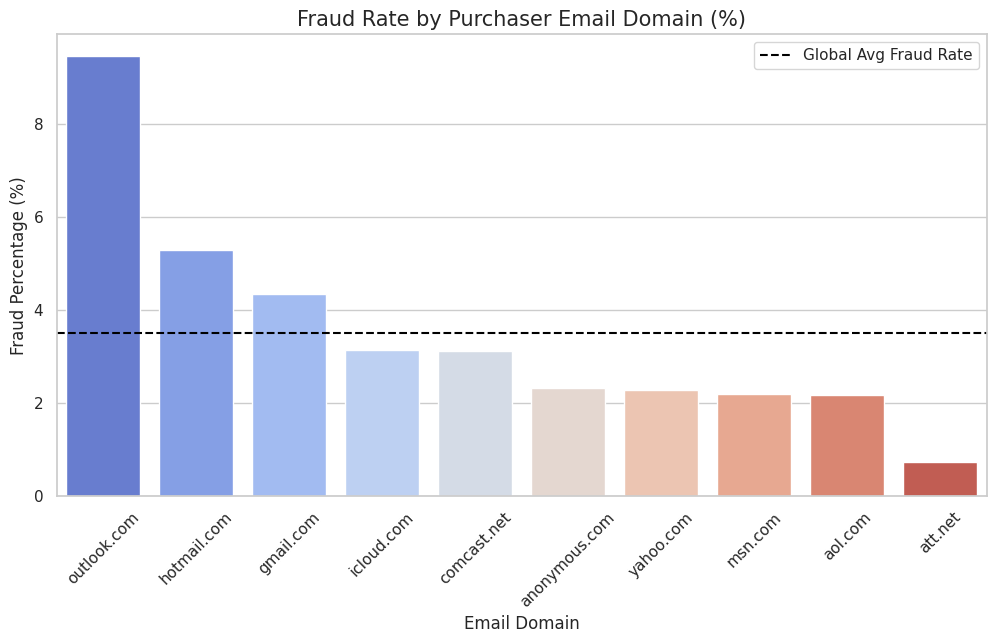

In [16]:
# Calculate fraud rate by email domain
top_emails = train['P_emaildomain'].value_counts().nlargest(10).index
email_data = train[train['P_emaildomain'].isin(top_emails)]

email_fraud_rate = email_data.groupby('P_emaildomain')['isFraud'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(12, 6))
sns.barplot(x=email_fraud_rate.index, y=email_fraud_rate.values, palette='coolwarm')
plt.title('Fraud Rate by Purchaser Email Domain (%)', fontsize=15)
plt.ylabel('Fraud Percentage (%)')
plt.xlabel('Email Domain')
plt.xticks(rotation=45)

# Add a horizontal line for the average fraud rate across the whole dataset
plt.axhline(train['isFraud'].mean() * 100, color='black', linestyle='--', label='Global Avg Fraud Rate')
plt.legend()
plt.show()

### 3.10. Fraud by Browser Type (id_31)
Identity feature `id_31` often contains browser information. We extract the top 10 browsers to see if outdated or specific automated "bot" browsers are being used for fraudulent transactions.

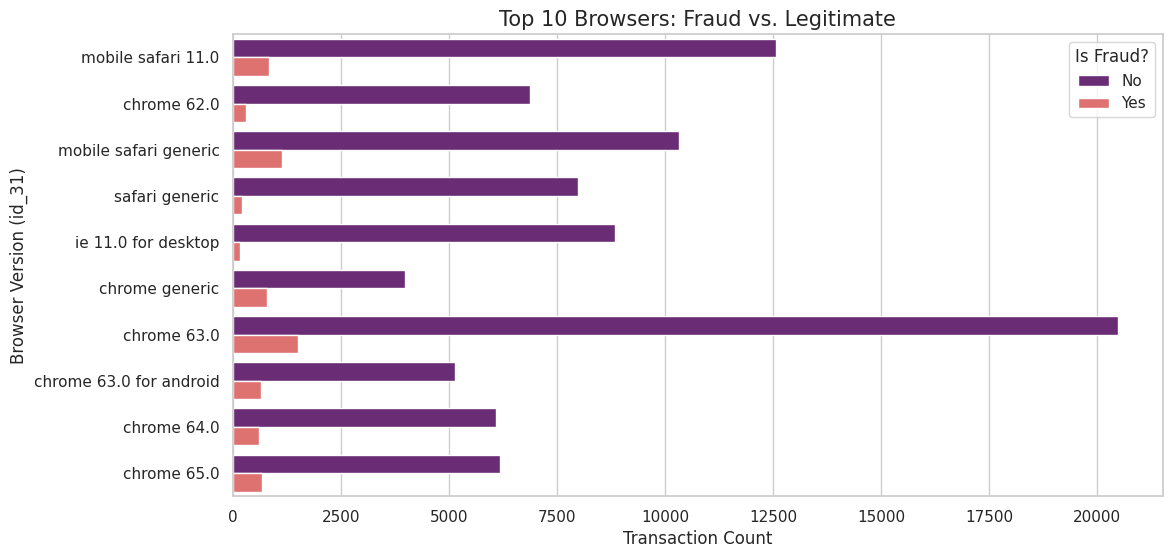

In [17]:
# Take top 10 browsers from identity data
top_browsers = train['id_31'].value_counts().nlargest(10).index
browser_data = train[train['id_31'].isin(top_browsers)]

plt.figure(figsize=(12, 6))
sns.countplot(data=browser_data, y='id_31', hue='isFraud', palette='magma')
plt.title('Top 10 Browsers: Fraud vs. Legitimate', fontsize=15)
plt.xlabel('Transaction Count')
plt.ylabel('Browser Version (id_31)')
plt.legend(title='Is Fraud?', labels=['No', 'Yes'])
plt.show()

## 4. Addressing Class Imbalance
With only 3.5% fraud cases, accuracy is a misleading metric. We implement Random Undersampling to create a balanced 50/50 training set, forcing the model to learn fraud characteristics.

In [7]:
# Separate classes
df_legit = train[train['isFraud'] == 0]
df_fraud = train[train['isFraud'] == 1]

# Undersample legitimate class to match fraud count
df_legit_under = resample(df_legit, replace=False, n_samples=len(df_fraud), random_state=42)

# Create balanced training set
train_balanced = pd.concat([df_fraud, df_legit_under])

print("Balanced Dataset Distribution:")
print(train_balanced['isFraud'].value_counts(normalize=True))

Balanced Dataset Distribution:
isFraud
1    0.5
0    0.5
Name: proportion, dtype: float64


### 4.1. Comparison of Class Distribution: Raw vs. Balanced
To validate the effectiveness of our undersampling strategy, we visualize the 'isFraud' distribution before and after the process. This shift from 3.5% to 50% fraud ensures the model focuses on feature patterns rather than class frequency.

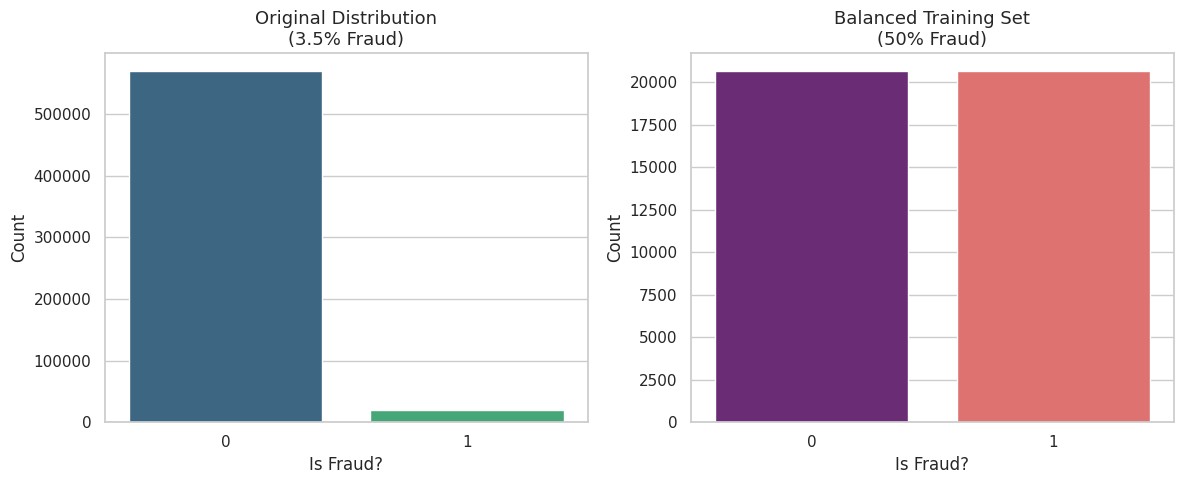

Original Fraud Count: 20663
Balanced Training Set Total: 41326


In [20]:
plt.figure(figsize=(12, 5))

# Plot 1: Original Imbalanced Distribution
plt.subplot(1, 2, 1)
# Fix: Assign x to hue and set legend=False to remove the warning
ax1 = sns.countplot(x='isFraud', data=train, hue='isFraud', palette='viridis', legend=False)
plt.title('Original Distribution\n(3.5% Fraud)', fontsize=13)
plt.xlabel('Is Fraud?')
plt.ylabel('Count')

# Plot 2: Balanced Training Distribution
plt.subplot(1, 2, 2)
# Fix: Assign x to hue and set legend=False to remove the warning
ax2 = sns.countplot(x='isFraud', data=train_balanced, hue='isFraud', palette='magma', legend=False)
plt.title('Balanced Training Set\n(50% Fraud)', fontsize=13)
plt.xlabel('Is Fraud?')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Final confirmation
print(f"Original Fraud Count: {len(train[train['isFraud']==1])}")
print(f"Balanced Training Set Total: {len(train_balanced)}")

## 5. Baseline Model Training (Random Forest)
We train a baseline model on the balanced dataset to establish a performance benchmark.

In [21]:
# Select key features
features = ['TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'null_count']
X = train_balanced[features].copy()
y = train_balanced['isFraud']

# Encode Categorical
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))

X = X.fillna(-999)

# Split and Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
clf = RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)
clf.fit(X_train, y_train)

# Results
probs = clf.predict_proba(X_test)[:, 1]
print(f"Baseline ROC-AUC Score: {roc_auc_score(y_test, probs):.4f}")

Baseline ROC-AUC Score: 0.8330
